version 2 - added random cropp, slidding window and stride

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt


In [5]:
WINDOW = 8
STRIDE = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [6]:
def createRow(n, classes):
    base = np.sin(np.linspace(
        np.random.rand(3),
        np.random.rand(3) + np.array([10, 15, 7]),
        n
    ))
    if classes[0] > 0:
        base[np.random.randint(0, n), 0] += 2
    if classes[1] > 0:
        base[np.random.randint(0, n), 1] -= 2
    if classes[2] > 0:
        x = np.random.randint(0, n-5)
        base[x:x+4, 2] = 0
    if classes[3] > 0:
        x = np.random.randint(0, n-10)
        base[x:x+8, 1] += 1.5
    if classes[4] > 0:
        x = np.random.randint(0, n-7)
        base[x:x+6, 0] += 1.5
        base[x:x+6, 2] -= 1.5
    base += np.random.rand(*base.shape) * 0.2
    return base


In [7]:
N = 50000
xl, yl = [], []

for _ in range(N):
    cl = np.random.rand(5) < 0.25
    xl.append(createRow(np.random.randint(40, 60), cl))
    yl.append(cl)


In [8]:
def random_crop(sequence, window=WINDOW):
    if len(sequence) <= window:
        return sequence
    start = np.random.randint(0, len(sequence) - window + 1)
    return sequence[start:start + window]


In [9]:
def sliding_windows(sequence, window=WINDOW, stride=STRIDE):
    if len(sequence) <= window:
        return [sequence]
    return [
        sequence[i:i+window]
        for i in range(0, len(sequence) - window + 1, stride)
    ]


In [10]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, train=True):
        self.X = X
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.train:
            x = random_crop(x)
        return x, self.y[idx]


In [11]:
def collate_fn(batch):
    sequences, labels = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences])
    sequences = [torch.from_numpy(seq).float() for seq in sequences]

    padded = nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True
    )

    labels = torch.from_numpy(np.array(labels)).float()
    return padded, lengths, labels


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    xl, yl, test_size=0.2, random_state=42
)

train_ds = TimeSeriesDataset(X_train, y_train, train=True)
test_ds  = TimeSeriesDataset(X_test, y_test, train=False)

train_loader = DataLoader(
    train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn
)


In [13]:
class TemporalDefectRNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, n_classes=5):
        super().__init__()
        self.rnn = nn.GRU(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.temporal_head = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True
        )
        logits = self.temporal_head(out)
        return torch.sigmoid(logits)


In [14]:
def aggregate_predictions(temporal_probs, lengths, mode="max"):
    outputs = []
    for i, L in enumerate(lengths):
        valid = temporal_probs[i, :L]
        if mode == "max":
            outputs.append(valid.max(dim=0).values)
        else:
            outputs.append(valid.mean(dim=0))
    return torch.stack(outputs)


In [15]:
model = TemporalDefectRNN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()


In [16]:
"""for epoch in range(20):
    model.train()
    total_loss = 0

    for x, lengths, y in train_loader:
        x = x.to(DEVICE)
        lengths = lengths.to(DEVICE)
        y = y.to(DEVICE)

        temporal_probs = model(x, lengths)
        seq_probs = aggregate_predictions(temporal_probs, lengths)

        loss = criterion(seq_probs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f}")
"""

'for epoch in range(20):\n    model.train()\n    total_loss = 0\n\n    for x, lengths, y in train_loader:\n        x = x.to(DEVICE)\n        lengths = lengths.to(DEVICE)\n        y = y.to(DEVICE)\n\n        temporal_probs = model(x, lengths)\n        seq_probs = aggregate_predictions(temporal_probs, lengths)\n\n        loss = criterion(seq_probs, y)\n\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n        total_loss += loss.item()\n\n    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f}")\n'

In [17]:
#torch.save(model.state_dict(), "temporal_defect_rnn.pth")


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TemporalDefectRNN(
    input_dim=3,
    hidden_dim=64,
    n_classes=5
).to(device)

state_dict = torch.load("temporal_defect_rnn.pth", map_location=device)
model.load_state_dict(state_dict)

model.eval()

TemporalDefectRNN(
  (rnn): GRU(3, 64, batch_first=True, bidirectional=True)
  (temporal_head): Linear(in_features=128, out_features=5, bias=True)
)

In [ ]:
def infer_sequence(model, sequence):
    windows = sliding_windows(sequence)

    xs = [torch.from_numpy(w).float() for w in windows]
    lengths = torch.tensor([len(w) for w in windows])

    x_pad = nn.utils.rnn.pad_sequence(xs, batch_first=True).to(DEVICE)
    lengths = lengths.to(DEVICE)

    with torch.no_grad():
        temporal_probs = model(x_pad, lengths)
        window_probs = aggregate_predictions(temporal_probs, lengths)

    return window_probs 


In [20]:
def aggregate_windows(window_probs, mode="max"):
    if mode == "max":
        return window_probs.max(dim=0).values
    return window_probs.mean(dim=0)


In [21]:
model.eval()
y_true, y_pred = [], []

for seq, label in zip(X_test, y_test):
    window_probs = infer_sequence(model, seq)
    seq_probs = aggregate_windows(window_probs)

    y_true.append(label)
    y_pred.append((seq_probs.cpu().numpy() > 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("F1 (macro):", f1_score(y_true, y_pred, average="macro"))
print("Accuracy :", accuracy_score(y_true, y_pred))


F1 (macro): 0.9802936343984662
Accuracy : 0.9513


In [22]:
import matplotlib.patches as patches

def visualize_batch_with_defects(
    model, X, y, indices,
    threshold=0.5, max_plots=10,
    window=12, stride=3
):
    model.eval()
    n = min(len(indices), max_plots)
    fig, axs = plt.subplots(n, 1, figsize=(14, 4*n), sharex=False)

    if n == 1:
        axs = [axs]

    colors = ["red", "purple", "cyan", "magenta", "yellow"]
    defect_names = [f"Defect {i}" for i in range(5)]
    defect_patches = [
        patches.Patch(color=colors[i], label=defect_names[i])
        for i in range(len(defect_names))
    ]

    device = next(model.parameters()).device

    for ax_idx, idx in enumerate(indices[:n]):
        seq_np = X[idx]
        T = len(seq_np)

        windows = sliding_windows(seq_np, window=window, stride=stride)

        xs = [torch.from_numpy(w).float() for w in windows]
        lengths = torch.tensor([len(w) for w in windows])

        x_pad = nn.utils.rnn.pad_sequence(xs, batch_first=True).to(device)
        lengths = lengths.to(device)

        with torch.no_grad():
            temporal_probs = model(x_pad, lengths)
            window_probs = aggregate_predictions(temporal_probs, lengths)
            window_probs = window_probs.cpu().numpy() 

        time_probs = np.zeros((T, window_probs.shape[1]))
        counts = np.zeros(T)

        for i, wp in enumerate(window_probs):
            start = i * stride
            end = min(start + window, T)
            time_probs[start:end] += wp
            counts[start:end] += 1

        time_probs /= counts[:, None]

        ax = axs[ax_idx]
        t = np.arange(T)

        ax.plot(t, seq_np[:, 0], label="Sensor 0", color="blue")
        ax.plot(t, seq_np[:, 1], label="Sensor 1", color="green")
        ax.plot(t, seq_np[:, 2], label="Sensor 2", color="orange")

        for k in range(time_probs.shape[1]):
            probs = time_probs[:, k]
            above_thr = probs > threshold

            start = None
            for i, val in enumerate(above_thr):
                if val and start is None:
                    start = i
                elif not val and start is not None:
                    end = i - 1
                    ax.add_patch(
                        patches.Rectangle(
                            (start, ax.get_ylim()[0]),
                            end - start + 1,
                            ax.get_ylim()[1] - ax.get_ylim()[0],
                            alpha=0.3,
                            color=colors[k % len(colors)]
                        )
                    )
                    start = None

            if start is not None:
                end = len(above_thr) - 1
                ax.add_patch(
                    patches.Rectangle(
                        (start, ax.get_ylim()[0]),
                        end - start + 1,
                        ax.get_ylim()[1] - ax.get_ylim()[0],
                        alpha=0.3,
                        color=colors[k % len(colors)]
                    )
                )

        ax.set_title(f"Sequence {idx} – True labels: {y[idx]}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Sensor value")

        if ax_idx == 0:
            sensor_lines = ax.lines[:3]
            ax.legend(handles=sensor_lines + defect_patches, loc="upper right")

    plt.tight_layout()
    plt.show()


C:\Users\julia\AppData\Local\Temp\ipykernel_24044\2070910491.py:50: RuntimeWarning: invalid value encountered in divide
  time_probs /= counts[:, None]


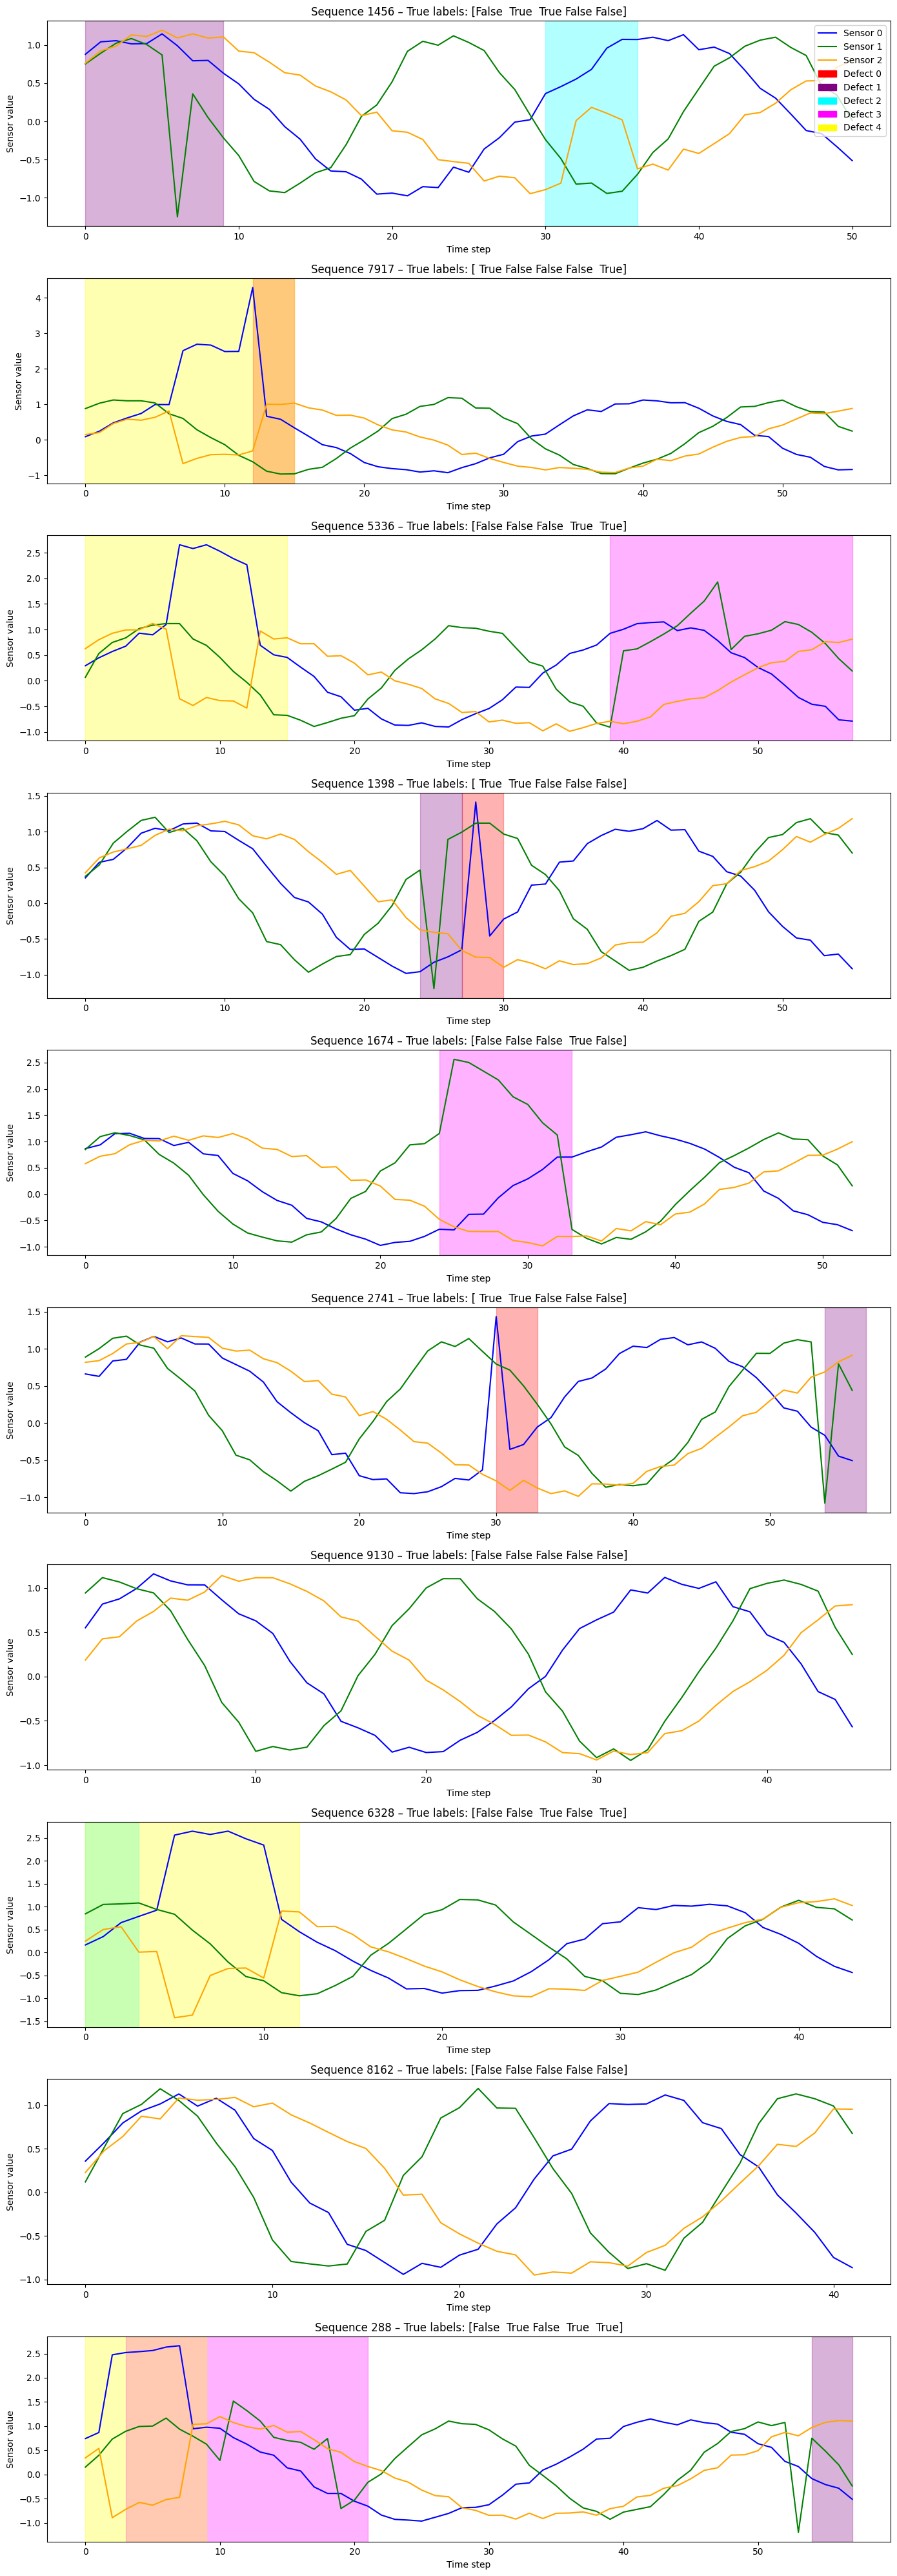

In [23]:
indices = np.random.choice(len(X_test), 10, replace=False)
visualize_batch_with_defects(model, X_test, y_test, indices=indices, threshold=0.95,max_plots=10)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def createRow_with_intervals(n, classes):
    base = np.sin(np.linspace(np.random.rand(3), np.random.rand(3) + np.array([10,15,7]), n))
    intervals = []

    if classes[0] > 0:
        idx = np.random.randint(0, n)
        base[idx, 0] += 2
        intervals.append((0, idx, idx))

    if classes[1] > 0:
        idx = np.random.randint(0, n)
        base[idx, 1] -= 2
        intervals.append((1, idx, idx))

    if classes[2] > 0:
        start = np.random.randint(0, n-5)
        base[start:start+4, 2] = 0
        intervals.append((2, start, start+3))

    if classes[3] > 0:
        start = np.random.randint(0, n-10)
        base[start:start+8, 1] += 1.5
        intervals.append((3, start, start+7))

    if classes[4] > 0:
        start = np.random.randint(0, n-7)
        base[start:start+6, 0] += 1.5
        base[start:start+6, 2] -= 1.5
        intervals.append((4, start, start+5))

    base += np.random.rand(*base.shape) * 0.2

    return base, intervals


def plot_random_sequences(num_sequences=10, min_len=40, max_len=60):
    colors = ["red", "purple", "cyan", "magenta", "yellow"]
    defect_names = [f"Defect {i}" for i in range(5)]
    
    fig, axs = plt.subplots(num_sequences, 1, figsize=(14, 4*num_sequences), sharex=False)
    if num_sequences == 1:
        axs = [axs]
    
    for i in range(num_sequences):
        n = np.random.randint(min_len, max_len+1)
        classes = np.random.rand(5) < 0.25  
        seq, intervals = createRow_with_intervals(n, classes)
        t = np.arange(n)
        
        ax = axs[i]
        ax.plot(t, seq[:,0], label="Sensor 0", color="blue")
        ax.plot(t, seq[:,1], label="Sensor 1", color="green")
        ax.plot(t, seq[:,2], label="Sensor 2", color="orange")
        
        for anomaly_idx, start, end in intervals:
            ax.add_patch(
                patches.Rectangle(
                    (start, ax.get_ylim()[0]),
                    end-start+1,
                    ax.get_ylim()[1]-ax.get_ylim()[0],
                    alpha=0.3,
                    color=colors[anomaly_idx % len(colors)]
                )
            )
            ax.text(start, ax.get_ylim()[1]*0.9, defect_names[anomaly_idx], color='white', fontsize=9)
        
        ax.set_title(f"Sequence {i} - Applied anomalies: {[a[0] for a in intervals]}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Sensor value")
        
        if i == 0:
            sensor_lines = [ax.lines[0], ax.lines[1], ax.lines[2]]
            defect_patches = [patches.Patch(color=colors[i], label=defect_names[i]) for i in range(5)]
            ax.legend(handles=sensor_lines + defect_patches, loc="upper right")
    
    plt.tight_layout()
    plt.show()


In [25]:
#plot_random_sequences(num_sequences=5, min_len=40, max_len=60)


In [36]:


def generate_dataset(num_sequences=20, min_len=40, max_len=60):
    X = []
    intervals_list = []

    for _ in range(num_sequences):
        n = np.random.randint(min_len, max_len + 1)
        classes = (np.random.rand(5) < 0.25).astype(int)

        seq, intervals = createRow_with_intervals(n, classes)

        X.append(seq)
        intervals_list.append(intervals)

    return X, intervals_list

def intervals_to_frame_labels(intervals, T, n_classes=5):
    y = np.zeros((T, n_classes), dtype=np.int32)
    for cls, start, end in intervals:
        y[start:end+1, cls] = 1
    return y


def visualize_and_evaluate_windowed(
    model, X, intervals_list,
    indices=None, threshold=0.5,
    max_plots=5, window=12, stride=3
):
    device = next(model.parameters()).device
    model.eval()

    colors = ["red", "purple", "cyan", "magenta", "yellow"]
    defect_names = [f"Defect {i}" for i in range(5)]
    defect_patches = [patches.Patch(color=colors[i], label=defect_names[i]) for i in range(5)]

    if indices is None:
        indices = list(range(min(max_plots, len(X))))

    n = min(len(indices), max_plots)
    fig, axs = plt.subplots(n, 1, figsize=(15, 4*n), sharex=False)
    if n == 1:
        axs = [axs]

    all_true, all_pred = [], []

    for seq_np, intervals in zip(X, intervals_list):
        T = len(seq_np)
        y_true = intervals_to_frame_labels(intervals, T)

        windows = sliding_windows(seq_np, window=window, stride=stride)
        xs = [torch.from_numpy(w).float() for w in windows]
        lengths = torch.tensor([len(w) for w in windows]).to(device)
        x_pad = nn.utils.rnn.pad_sequence(xs, batch_first=True).to(device)

        with torch.no_grad():
            temporal_probs = model(x_pad, lengths)
            window_probs = aggregate_predictions(temporal_probs, lengths)
            window_probs = window_probs.cpu().numpy()

        time_probs = np.zeros((T, window_probs.shape[1]))
        counts = np.zeros(T)
        for i, wp in enumerate(window_probs):
            start = i * stride
            end = min(start + window, T)
            time_probs[start:end] += wp
            counts[start:end] += 1
        time_probs /= counts[:, None]

        y_pred = (time_probs >= threshold).astype(int)

        all_true.append(y_true)
        all_pred.append(y_pred)

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    metrics = {}
    for c in range(y_true_all.shape[1]):
        metrics[f"Defect {c}"] = {
            "accuracy": accuracy_score(y_true_all[:, c], y_pred_all[:, c]),
            "f1": f1_score(y_true_all[:, c], y_pred_all[:, c], zero_division=0)
        }
    metrics["macro_f1"] = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)

    for ax_idx, idx in enumerate(indices[:n]):
        seq_np = X[idx]
        intervals = intervals_list[idx]
        T = len(seq_np)

        windows = sliding_windows(seq_np, window=window, stride=stride)
        xs = [torch.from_numpy(w).float() for w in windows]
        lengths = torch.tensor([len(w) for w in windows]).to(device)
        x_pad = nn.utils.rnn.pad_sequence(xs, batch_first=True).to(device)

        with torch.no_grad():
            temporal_probs = model(x_pad, lengths)
            window_probs = aggregate_predictions(temporal_probs, lengths)
            window_probs = window_probs.cpu().numpy()

        time_probs = np.zeros((T, window_probs.shape[1]))
        counts = np.zeros(T)
        for i, wp in enumerate(window_probs):
            start = i * stride
            end = min(start + window, T)
            time_probs[start:end] += wp
            counts[start:end] += 1
        time_probs /= counts[:, None]

        ax = axs[ax_idx]
        t = np.arange(T)
        ax.plot(t, seq_np[:, 0], label="Sensor 0", color="blue")
        ax.plot(t, seq_np[:, 1], label="Sensor 1", color="green")
        ax.plot(t, seq_np[:, 2], label="Sensor 2", color="orange")

        ymin, ymax = ax.get_ylim()

        for cls, start, end in intervals:
            ax.add_patch(
                patches.Rectangle((start, ymin), end-start+1, ymax-ymin,
                                  alpha=0.35, color=colors[cls])
            )

        for cls in range(time_probs.shape[1]):
            active = (time_probs[:, cls] >= threshold)
            start = None
            for i, v in enumerate(active):
                if v and start is None:
                    start = i
                elif not v and start is not None:
                    ax.add_patch(
                        patches.Rectangle((start, ymin), i-start, ymax-ymin,
                                          fill=False, hatch="///",
                                          edgecolor=colors[cls], linewidth=2)
                    )
                    start = None
            if start is not None:
                ax.add_patch(
                    patches.Rectangle((start, ymin), T-start, ymax-ymin,
                                      fill=False, hatch="///",
                                      edgecolor=colors[cls], linewidth=2)
                )

        ax.set_title(f"Sequence {idx}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Sensor value")

        if ax_idx == 0:
            sensor_lines = ax.lines[:3]
            ax.legend(handles=sensor_lines + defect_patches, loc="upper right")

    plt.tight_layout()
    plt.show()

    return metrics


C:\Users\julia\AppData\Local\Temp\ipykernel_24044\831147626.py:66: RuntimeWarning: invalid value encountered in divide
  time_probs /= counts[:, None]
C:\Users\julia\AppData\Local\Temp\ipykernel_24044\831147626.py:106: RuntimeWarning: invalid value encountered in divide
  time_probs /= counts[:, None]


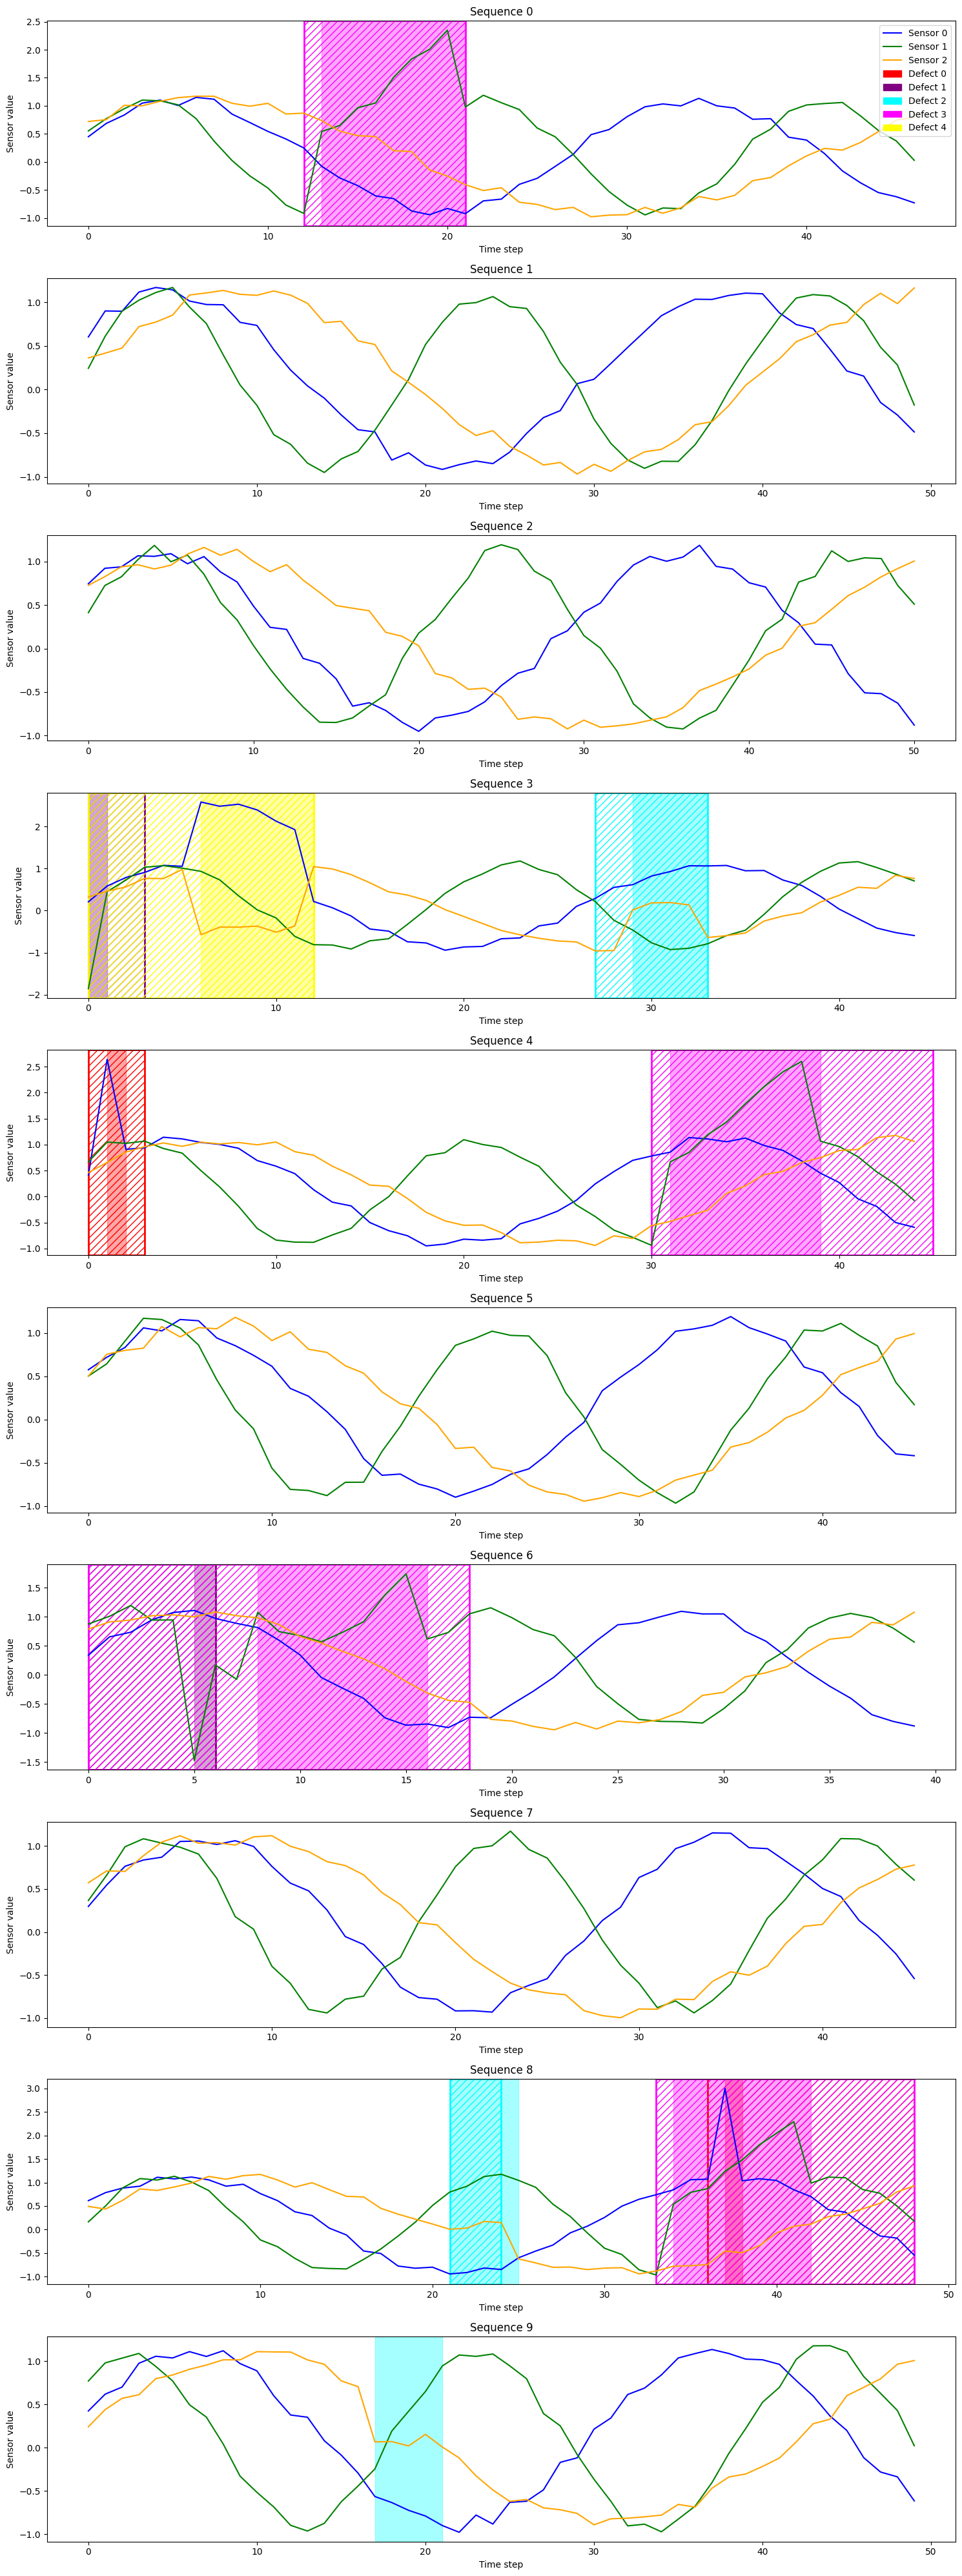

Defect 0 {'accuracy': 0.9740437158469946, 'f1': 0.2692307692307692}
Defect 1 {'accuracy': 0.9842896174863388, 'f1': 0.3783783783783784}
Defect 2 {'accuracy': 0.9890710382513661, 'f1': 0.7419354838709677}
Defect 3 {'accuracy': 0.9719945355191257, 'f1': 0.757396449704142}
Defect 4 {'accuracy': 0.9760928961748634, 'f1': 0.7286821705426356}
macro_f1 0.5751246503453786


In [37]:
X, intervals_list = generate_dataset(num_sequences=30)

metrics = visualize_and_evaluate_windowed(
    model,
    X,
    intervals_list,
    indices=list(range(10)),   
    threshold=0.95,
    max_plots=20              
)

for k, v in metrics.items():
    print(k, v)
